<h2>Taux chomage par département</h2>

<h3>Import et cleaning des données</h3>

Données CVS, en moyenne trimestrielle (en %).<br>
Source : Insee, estimations de taux de chômage localisés et taux de chômage au sens du BIT.

In [1]:
import pandas as pd
import plotly.express as px

data_chomage = pd.read_excel('sl_etc_2025T4.xls', sheet_name=1)
data_chomage.head()

,Estimations de taux de chômage localisé : comparaisons départementales,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176,Unnamed: 177
0,(en%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Code,Libellé,T1_1982,T2_1982,T3_1982,T4_1982,T1_1983,T2_1983,T3_1983,T4_1983,...,T3_2023,T4_2023,T1_2024,T2_2024,T3_2024,T4_2024,T1_2025,T2_2025,T3_2025,T4_2025
3,01,AIN,3.8,3.9,4,4.1,4.2,4.2,4.4,4.6,...,5.6,5.7,5.6,5.5,5.5,5.5,5.6,5.6,5.7,5.8
4,02,AISNE,8.2,8.4,8.5,8.4,8.5,8.5,8.7,9.1,...,10.5,10.7,10.7,10.5,10.5,10,10.2,10.2,10.4,10.6


Dans un premier temps, nous allons "nettoyer" le dataset, en ne gardant que les données qui nous intéressent, puis nous modifierons le nom des colonnes

In [2]:
# on récupère les noms des colonnes
cles = list(data_chomage.columns)

In [3]:
# on récupère les "vrais noms" des colonnes
valeurs = list(data_chomage.iloc[2,:])

In [4]:
# on crée un dictionnaire pour changer le nom des colonnes
dico = dict(zip(cles, valeurs))

In [5]:
# on garde les données qui nous intéressent puis on renomme les colonnes
df_chom_dep = data_chomage.iloc[3:103,:].rename(columns=dico).reset_index(drop=True).copy()
df_chom_dep.head()

,Code,Libellé,T1_1982,T2_1982,T3_1982,T4_1982,T1_1983,T2_1983,T3_1983,T4_1983,...,T3_2023,T4_2023,T1_2024,T2_2024,T3_2024,T4_2024,T1_2025,T2_2025,T3_2025,T4_2025
0,01,AIN,3.8,3.9,4,4.1,4.2,4.2,4.4,4.6,...,5.6,5.7,5.6,5.5,5.5,5.5,5.6,5.6,5.7,5.8
1,02,AISNE,8.2,8.4,8.5,8.4,8.5,8.5,8.7,9.1,...,10.5,10.7,10.7,10.5,10.5,10,10.2,10.2,10.4,10.6
2,03,ALLIER,7.3,7.5,7.7,7.7,7.7,7.7,7.8,8.4,...,7.8,7.9,7.9,7.9,7.9,7.8,7.8,7.9,8,8.2
3,04,ALPES-DE-HAUTE-PROVENCE,5.5,5.7,5.8,6,6.2,6.1,6.3,6.6,...,8.3,8.2,8.1,7.9,8,7.7,7.9,7.9,8,8.2
4,05,HAUTES-ALPES,4.9,4.9,5,5.3,5.7,5.8,6,6.4,...,6.6,6.6,6.5,6.2,6.2,6,6.2,6.4,6.4,6.5


<h2>Data modeling</h2>

On souhaite faire une correspondance entre les données de ce dataset et ceux d'un dataset sur la délinquance en fonction des années. On va transformer notre dataset en faisant une moyenne sur les quatres trimestres afin d'avoir des taux par an.

In [6]:
for annee in range(1982, 2026):
    df_chom_dep[f'{annee}'] = (df_chom_dep[f'T1_{annee}'] + df_chom_dep[f'T2_{annee}'] + df_chom_dep[f'T3_{annee}'] + df_chom_dep[f'T4_{annee}'])/4
    df_chom_dep.drop([f'T1_{annee}',f'T2_{annee}',f'T3_{annee}',f'T4_{annee}'], axis=1, inplace=True)

df_chom_dep.head()    

,Code,Libellé,1982,1983,1984,1985,1986,1987,1988,1989,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,01,AIN,3.95,4.35,5.225,5.475,5.375,5.325,4.925,4.35,...,7.35,6.75,6.3,6.05,6.075,5.9,5.4,5.475,5.525,5.675
1,02,AISNE,8.375,8.7,10.15,10.375,10.425,10.4,10.2,9.3,...,13.625,12.975,12.375,11.6,10.975,10.95,10.35,10.45,10.425,10.35
2,03,ALLIER,7.55,7.9,10.2,10.6,10.775,10.95,10.575,10.05,...,10.375,9.7,9.35,8.9,8.45,8.15,7.625,7.725,7.875,7.975
3,04,ALPES-DE-HAUTE-PROVENCE,5.75,6.3,7.1,7.6,7.475,7.15,6.9,6.7,...,11.075,10.7,10.4,9.75,9.125,8.825,8.225,8.125,7.925,8.0
4,05,HAUTES-ALPES,5.025,5.975,6.725,6.725,6.775,6.7,6.625,6.725,...,9.25,8.675,8.475,7.975,7.675,7.95,6.75,6.55,6.225,6.375


Nous allons faire un pivot pour avoir une seule colonne 'Annee'

In [7]:
chom_dp = df_chom_dep.melt(
    id_vars=['Code', 'Libellé'],          # colonne à garder fixe
    var_name='Annee',        # nom de la nouvelle colonne (ex-colonnes)
    value_name='Taux de chomage (%)'      # nom des valeurs
)
chom_dp = chom_dp.sort_values(by=['Libellé', 'Annee']).reset_index(drop=True)
chom_dp.head()

,Code,Libellé,Annee,Taux de chomage (%)
0,01,AIN,1982,3.95
1,01,AIN,1983,4.35
2,01,AIN,1984,5.225
3,01,AIN,1985,5.475
4,01,AIN,1986,5.375


Notre dataset est prêt pour un traitement futur, nous allons le sauvegarder dans un fichier csv

In [8]:
chom_dp.to_csv('chomageDepL.csv')

<h2>Coordonnées GPS des départements</h2>

Source: IGN, url :https://www.ign.fr/mag/quel-est-le-centre-geographique-des-96-departements-metropolitains <br>
Le dataset donne le centre géographique des 96 départements métropolitains. 

In [9]:
C = pd.read_excel('Centre_departement.xlsx')
centre_dep = C.copy()
centre_dep.head()

,Départements métropolitains,Unnamed: 1,Aire (km²),Centre (« de gravité sur l'ellipsoïde »),Unnamed: 4,Unnamed: 5
0,NaN,NaN,NaN,"Ʌ (° ' """")","ɸ (° ' """")",Commune
1,01,Ain,5785.0,"5°20'56"" E","46°05'58""",01160 Saint-Martin-du-Mont
2,02,Aisne,7419.0,"3°33'30"" E","49°33'34""",02000 Clacy-et-Thierret
3,03,Allier,7380.0,"3°11'18"" E","46°23'37""",03240 Treban
4,04,Alpes-de-Haute-Provence,6996.0,"6°14'38"" E","44°06'22""",04000 Digne-les-Bains


<h3>Cleaning et optimisation</h3>

In [10]:
data_dp = centre_dep.iloc[1:,:5]
data_dp.drop('Aire (km²)', axis=1, inplace=True)

In [11]:
data_dp = data_dp.rename(columns={'Départements métropolitains':'Code',
                       'Unnamed: 1':'Libellé',
                       'Centre (« de gravité sur l\'ellipsoïde »)':'lon',
                       'Unnamed: 4':'lat'}
              )
data_dp.head()

,Code,Libellé,lon,lat
1,01,Ain,"5°20'56"" E","46°05'58"""
2,02,Aisne,"3°33'30"" E","49°33'34"""
3,03,Allier,"3°11'18"" E","46°23'37"""
4,04,Alpes-de-Haute-Provence,"6°14'38"" E","44°06'22"""
5,05,Hautes-Alpes,"6°15'47"" E","44°39'49"""


On définie une fonction qui va transformer le format des coordonnées afin d'etre lisible par plotly pour effectuer nos visualisations

In [12]:
def dms_to_dd(coord):
    L = coord.split('°')
    deg = int(L[0])
    L2 = L[1].split()
    temps = L2[0]
    minutes = int(temps[:2])
    seconds = int(temps[3:5])
    direction = L2[-1]
    
    dd = deg + minutes/60 + seconds/3600
    if direction in ['W', 'S']:
        dd *= -1
    return dd

In [13]:
data_dp['lon'] = data_dp['lon'].apply(dms_to_dd)
data_dp['lat'] = data_dp['lat'].apply(dms_to_dd)
data_dp.head()

,Code,Libellé,lon,lat
1,01,Ain,5.348889,46.099444
2,02,Aisne,3.558333,49.559444
3,03,Allier,3.188333,46.393611
4,04,Alpes-de-Haute-Provence,6.243889,44.106111
5,05,Hautes-Alpes,6.263056,44.663611


On souhaite à présent faire une visualisation des taux de chomage par département au cours du temps, pour se faire nous allons d'abord combiner les deux dataset.

In [14]:
coord_dp = data_dp[['Code','lon','lat']].copy()
coord_dp.head()

,Code,lon,lat
1,01,5.348889,46.099444
2,02,3.558333,49.559444
3,03,3.188333,46.393611
4,04,6.243889,44.106111
5,05,6.263056,44.663611


On s'assure que les deux colonnes 'Code' soient de type string

In [15]:
coord_dp['Code'] = coord_dp['Code'].astype(str)

In [16]:
chom_dp['Code'] = chom_dp['Code'].astype(str)

In [17]:
chom_coord_df = pd.merge(chom_dp, coord_dp, on='Code')
chom_coord_df.head()

,Code,Libellé,Annee,Taux de chomage (%),lon,lat
0,01,AIN,1982,3.95,5.348889,46.099444
1,01,AIN,1983,4.35,5.348889,46.099444
2,01,AIN,1984,5.225,5.348889,46.099444
3,01,AIN,1985,5.475,5.348889,46.099444
4,01,AIN,1986,5.375,5.348889,46.099444


In [18]:
chom_coord_df['Taux de chomage (%)'] = chom_coord_df['Taux de chomage (%)'].astype(float)

NB: pour la visualisation qui va suivre, le second dataset de l'IGN n'était pas nécessaire. Mais nous gardons toutefois notre nouveau dataframe pour effectuer la visualisation et pour une utilisation future.

<h2>Visualistion des données</h2>

In [ ]:
import json

with open("departements.geojson") as f:
    geojson = json.load(f)

fig = px.choropleth(
    chom_coord_df,
    geojson=geojson,
    locations="Code",        
    featureidkey="properties.code",
    color="Taux de chomage (%)",
    hover_name="Libellé",
    animation_frame="Annee",
    color_continuous_scale="Reds",
    title="Taux de chômage (%) par région"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    width=800,
    height=500,
    margin={"r":0, "t":40, "l":0, "b":0},
    coloraxis_colorbar=dict(title="Taux (%)")
)

fig.show()

<b>Le chômage présente une structure spatiale marquée, avec des niveaux plus élevés dans le Nord, le Sud et certaines zones de l'Ouest. Cette hétérogénéité est globalement stable dans le temps.<b>

<h3>Moyenne nationale par année</h3>

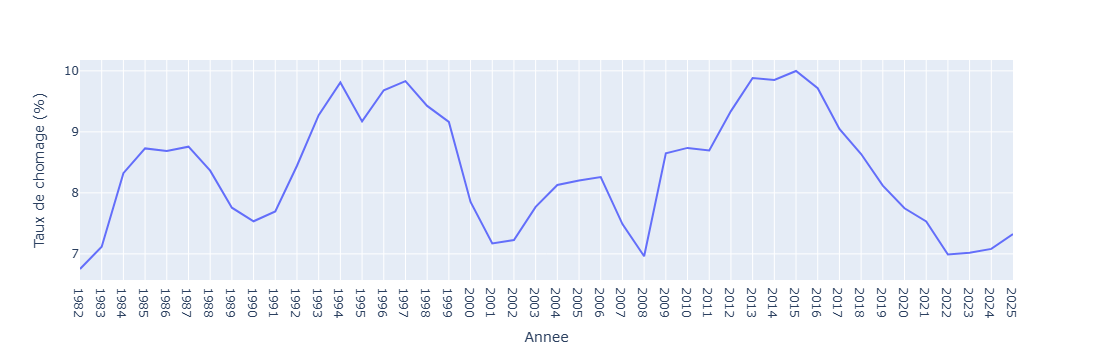

In [23]:
px.line(chom_coord_df.groupby("Annee")["Taux de chomage (%)"].mean().reset_index(),
        x="Annee", y="Taux de chomage (%)")

<b>La moyenne nationale du taux de chômage présente une dynamique en “double bosse”, avec deux pics autour de 1995 et 2015, suggérant des phases de tension économique suivies de périodes de stabilisation.<b>

<h3>Analyse des écarts entre départements</h3>

Variance entre départements

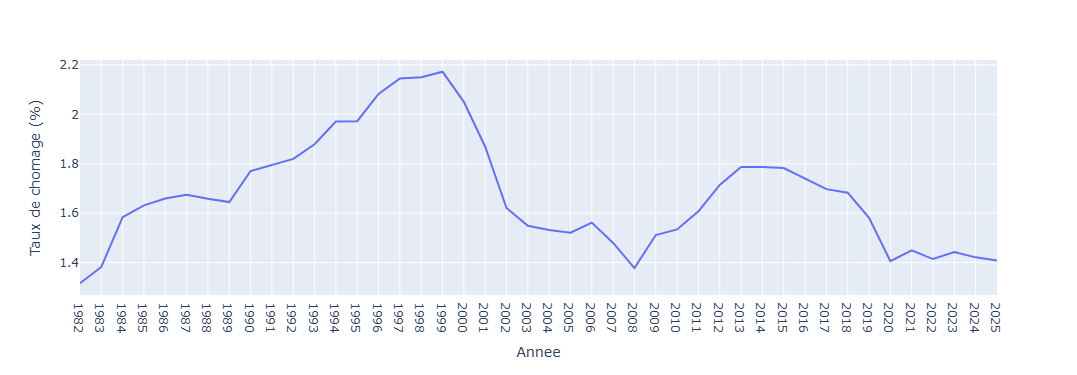

In [22]:
px.line(chom_coord_df.groupby("Annee")["Taux de chomage (%)"].std().reset_index(), x="Annee", y="Taux de chomage (%)")

<b>La variance inter-départementale suit une dynamique similaire à la moyenne nationale, avec un maximum autour de 1999 (≈ 2,17), puis une stabilisation autour de 1,5.<b>

<h3>Interprétation</h3>

L’analyse suggère que le chômage en France est principalement structuré par des effets spatiaux persistants, tandis que les fluctuations temporelles affectent uniformément les territoires sans modifier fondamentalement les disparités régionales.